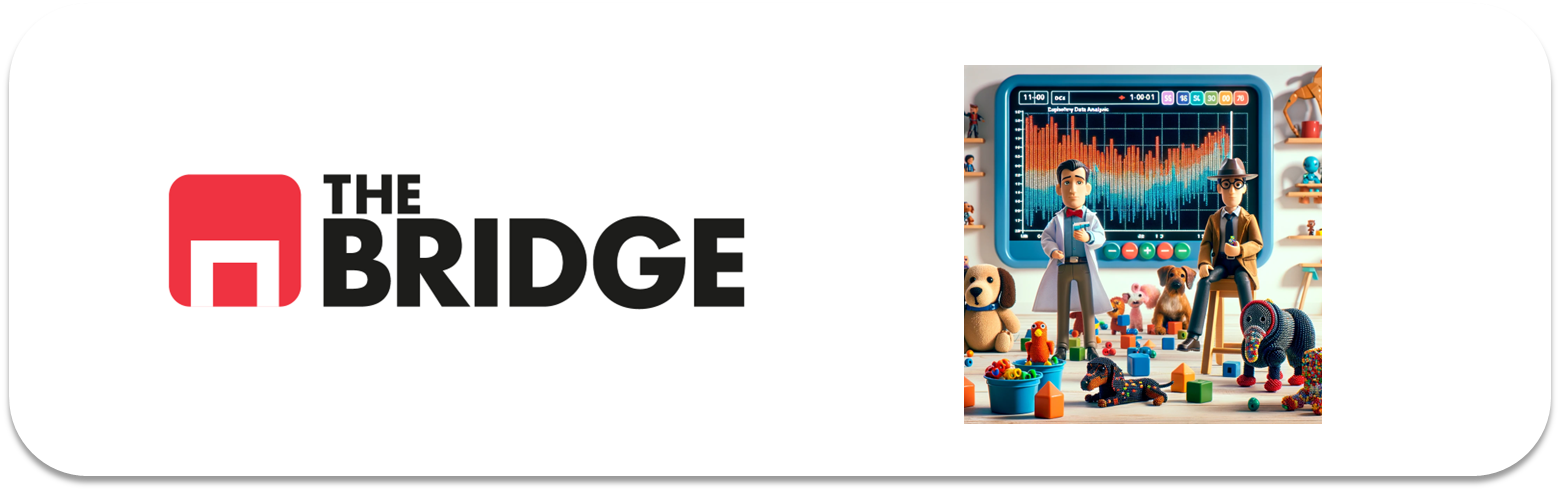

## PRACTICA OBLIGATORIA: **Análisis Multivariante**

* La práctica obligatoria de esta unidad consiste en completar el análisis del dataset del Titanic, dirigido por una serie de preguntas, y de terminar de analizar algunos aspectos del dataset de viajes. Descarga este notebook en tu ordenador y trabaja en local. Ten en cuenta que tendrás que descar los directorios de imágenes y datos adicionales, si los hubiera.
* Recuerda que debes subirla a tu repositorio personal antes de la sesión en vivo para que puntúe adecuadamente.  
* Recuerda también que no es necesario que esté perfecta, sólo es necesario que se vea el esfuerzo. 
* Esta práctica se resolverá en la sesión en vivo correspondiente y la solución se publicará en el repo del curso. 

### Ejercicio 0


Importa los paquetes y módulos que necesites a lo largo del notebook

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import chi2_contingency, mannwhitneyu

sns.set_theme(style="whitegrid")
pd.set_option('display.max_columns', 20)

## #1: Titanic

### #1.1

Carga en un dataframe el dataset del titanic, que está en la ruta "./data/titanic.csv".

In [2]:
df = pd.read_csv("./data/titanic.csv")

print("Shape:", df.shape)
print("\nPrimeras filas:")
df.head()

Shape: (891, 15)

Primeras filas:


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


### #1.2

Deshazte de las columnas "deck", "survived", "pclass" y "embarked" porque no las emplearemos, la primera por su cantidad de nulos y el resto porque son variantes de otras que ya existen y cuyos valores resultan más expresivos a la hora de hacer un análisis. 

In [3]:
df.drop(columns=['deck', 'survived', 'pclass', 'embarked'], inplace=True)

print("Columnas restantes:", df.columns.tolist())
print("Shape:", df.shape)

Columnas restantes: ['sex', 'age', 'sibsp', 'parch', 'fare', 'class', 'who', 'adult_male', 'embark_town', 'alive', 'alone']
Shape: (891, 11)


### #1.3

Suma las columnas "parch" y "sibsp" para tener el número de parientes de cada pasajero, guarda el resultado en otra columna "family_members", luego deshazte de "parch" y "sibsp"

In [4]:
df['family_members'] = df['parch'] + df['sibsp']
df.drop(columns=['parch', 'sibsp'], inplace=True)

print("Distribución de family_members:")
print(df['family_members'].value_counts().sort_index())

Distribución de family_members:
family_members
0     537
1     161
2     102
3      29
4      15
5      22
6      12
7       6
10      7
Name: count, dtype: int64


### #1.4

Imputa la moda a los valores nulos de "embark_town"

In [5]:
moda_town = df['embark_town'].mode()[0]
df['embark_town'] = df['embark_town'].fillna(moda_town)

print("Moda imputada:", moda_town)
print("Nulos restantes en embark_town:", df['embark_town'].isnull().sum())
print("\nDistribución por ciudad:")
print(df['embark_town'].value_counts())

Moda imputada: Southampton
Nulos restantes en embark_town: 0

Distribución por ciudad:
embark_town
Southampton    646
Cherbourg      168
Queenstown      77
Name: count, dtype: int64


### #1.5

Imputa la media a los valores faltantes de "age", si quieres puedes hacer algo más preciso (por ejemplo considerando además la columna "who")

In [6]:
media_age = df['age'].mean()
df['age'] = df['age'].fillna(media_age)

print(f"Media imputada: {media_age:.2f} años")
print("Nulos restantes en age:", df['age'].isnull().sum())
print("\nVerificación de nulos en todo el dataset:")
print(df.isnull().sum())

Media imputada: 29.70 años
Nulos restantes en age: 0

Verificación de nulos en todo el dataset:
sex               0
age               0
fare              0
class             0
who               0
adult_male        0
embark_town       0
alive             0
alone             0
family_members    0
dtype: int64


### #1.6

Realiza los análisis bivariantes o multivariantes que necesites, así como los test de hipótesis necesarios para contestar a las siguientes preguntas. Nota: utiliza la variable "alive" para saber si un pasajero sobrevivió o no:

1. En términos absolutos, ¿sobrevivieron más hombres, mujeres o niños? ¿Y en términos relativos? ¿Existe alguna relación estadísticamente significativa entre el sexo y la supervivencia en el Titanic?¿Y entre ser adulto o ser niño?

2. En términos absolutos, ¿de que clase sobrevivieron más pasajeros?¿ Y en términos relativos? ¿Existe alguna relación estadísticamente significativa entre la clase en la que se viajaba y la supervivencia?

3. ¿De qué ciudad sobrevivieron más personas?¿Y porcentualmente de que ciudad sobrevivieron más personas? ¿Hay alguna relación estadística significativa entre haber embarcado en una de las tres ciudades y haber sobrevivido o fallecido?

4. ¿Qué relación hay entre el precio del pasaje y la supervivencia/fallecimiento?

5. Existen pasajero que no pagaron el billete, ¿podrías explicar por qué? ¿Qué ocurrió con la persona que más dinero se dejó?

6. Existe alguna relación entre el dinero pagado, la ciudad de embarque y la superviviencia/fallecimiento. No necesitas aplicar ningún test, muestralo numérica o visualmente.

7. Ahondando en la relación entre sobrevivir o fallecer, la clase en la que se viajó y la edad de los pasajeros. ¿Qué agrupación de las dos variables (clase y edad) sobrevivió más en términos absolutos y en términos relativos?

8. Finalmente, muestra las posibles relaciones entre edad, coste del billete y supervivencia/fallecimiento. ¿Qué puedes decir al respecto?

Supervivencia en términos ABSOLUTOS:
alive   no  yes
who            
child   34   49
man    449   88
woman   66  205

Supervivencia en términos RELATIVOS (%):
alive    no   yes
who              
child  41.0  59.0
man    83.6  16.4
woman  24.4  75.6


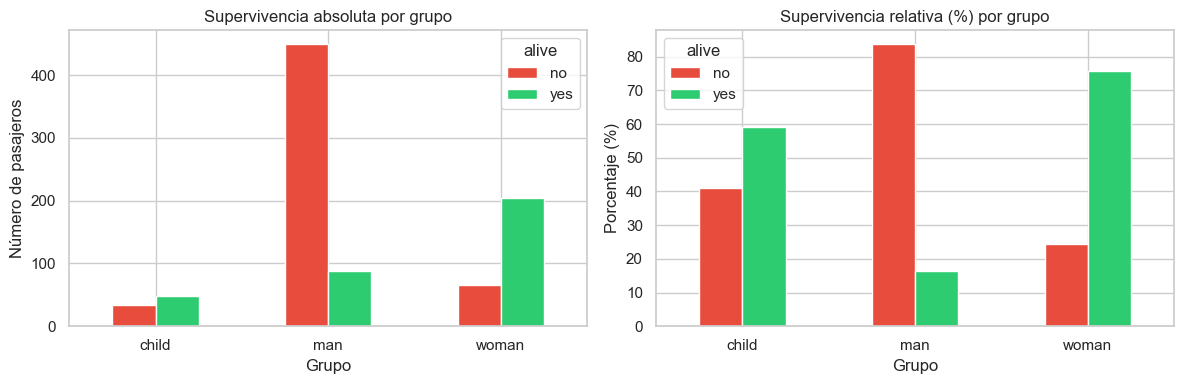

Test Chi² (hombre vs mujer y supervivencia): chi2=271.08, p=0.000000
Relación estadísticamente significativa

Test Chi² (adulto vs niño y supervivencia): chi2=15.56, p=0.000080
Relación estadísticamente significativa


In [7]:
#1

abs_tabla = pd.crosstab(df['who'], df['alive'])
rel_tabla = pd.crosstab(df['who'], df['alive'], normalize='index').round(3) * 100

print("Supervivencia en términos ABSOLUTOS:")
print(abs_tabla)
print("\nSupervivencia en términos RELATIVOS (%):")
print(rel_tabla)


fig, axes = plt.subplots(1, 2, figsize=(12, 4))

abs_tabla.plot(kind='bar', ax=axes[0], color=['#e74c3c','#2ecc71'], rot=0)
axes[0].set_title("Supervivencia absoluta por grupo")
axes[0].set_xlabel("Grupo"); axes[0].set_ylabel("Número de pasajeros")

rel_tabla.plot(kind='bar', ax=axes[1], color=['#e74c3c','#2ecc71'], rot=0)
axes[1].set_title("Supervivencia relativa (%) por grupo")
axes[1].set_xlabel("Grupo"); axes[1].set_ylabel("Porcentaje (%)")

plt.tight_layout()
plt.show()

#solo adultos para aislar el sexo
df_adultos = df[df['who'] != 'child']
tabla_sexo = pd.crosstab(df_adultos['who'], df_adultos['alive'])
chi2, p, dof, exp = chi2_contingency(tabla_sexo)
print(f"Test Chi² (hombre vs mujer y supervivencia): chi2={chi2:.2f}, p={p:.6f}")
print("Relación estadísticamente significativa" if p < 0.05 else "No significativa")

#adulto vs niño vs alive
df['es_nino'] = df['who'].apply(lambda x: 'child' if x == 'child' else 'adult')
tabla_nino = pd.crosstab(df['es_nino'], df['alive'])
chi2_n, p_n, _, _ = chi2_contingency(tabla_nino)
print(f"\nTest Chi² (adulto vs niño y supervivencia): chi2={chi2_n:.2f}, p={p_n:.6f}")
print("Relación estadísticamente significativa" if p_n < 0.05 else "No significativa")


**Conclusión:** En términos absolutos sobrevivieron más mujeres (205), seguidas de hombres (88) y niños (49). En términos **relativos**, las mujeres tuvieron la mayor tasa de supervivencia (76%), seguidas de niños (59%) y hombres (solo el 16%). Ambos tests Chi² son altamente significativos (p ≈ 0), confirmando la relación entre el grupo y la supervivencia.

Absoluto:
alive    no  yes
class           
First    80  136
Second   97   87
Third   372  119

Relativo (%):
alive     no   yes
class             
First   37.0  63.0
Second  52.7  47.3
Third   75.8  24.2


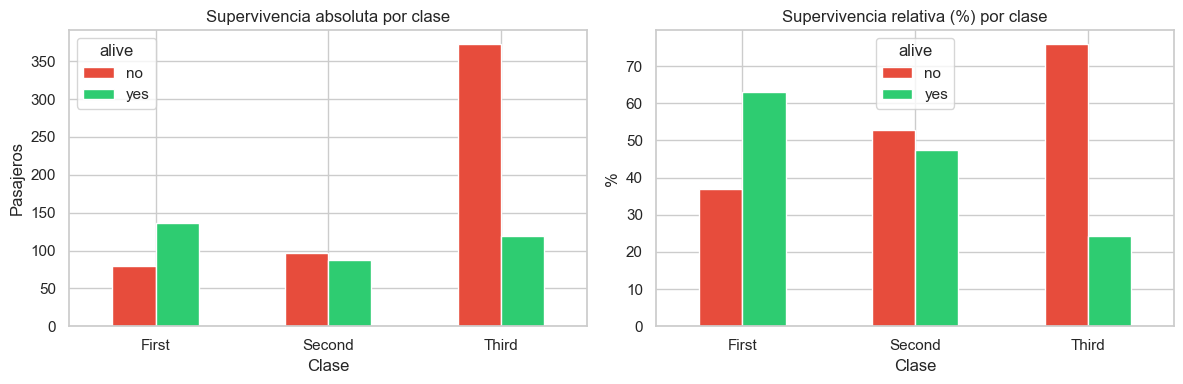

Test Chi² (clase vs supervivencia): chi2=102.89, p=0.000000
Relación estadísticamente significativa


In [8]:
#2

abs_clase = pd.crosstab(df['class'], df['alive'])
rel_clase = pd.crosstab(df['class'], df['alive'], normalize='index').round(3) * 100

print("Absoluto:")
print(abs_clase)
print("\nRelativo (%):")
print(rel_clase)


fig, axes = plt.subplots(1, 2, figsize=(12, 4))
orden = ['First', 'Second', 'Third']

abs_clase.loc[orden].plot(kind='bar', ax=axes[0], color=['#e74c3c','#2ecc71'], rot=0)
axes[0].set_title("Supervivencia absoluta por clase")
axes[0].set_xlabel("Clase"); axes[0].set_ylabel("Pasajeros")

rel_clase.loc[orden].plot(kind='bar', ax=axes[1], color=['#e74c3c','#2ecc71'], rot=0)
axes[1].set_title("Supervivencia relativa (%) por clase")
axes[1].set_xlabel("Clase"); axes[1].set_ylabel("%")

plt.tight_layout()
plt.show()


chi2, p, dof, exp = chi2_contingency(abs_clase)
print(f"Test Chi² (clase vs supervivencia): chi2={chi2:.2f}, p={p:.6f}")
print("Relación estadísticamente significativa" if p < 0.05 else "No significativa")

**Conclusión:** En absoluto, la tercera clase perdió a más personas (372 muertos), pero también tenía más pasajeros. En relativo, la **primera clase** tuvo la mayor tasa de supervivencia (63%), frente al 47% de segunda y solo el 24% de tercera. El test Chi² confirma una relación significativa entre clase y supervivencia.

Absoluto:
alive         no  yes
embark_town          
Cherbourg     75   93
Queenstown    47   30
Southampton  427  219

Relativo (%):
alive          no   yes
embark_town            
Cherbourg    44.6  55.4
Queenstown   61.0  39.0
Southampton  66.1  33.9


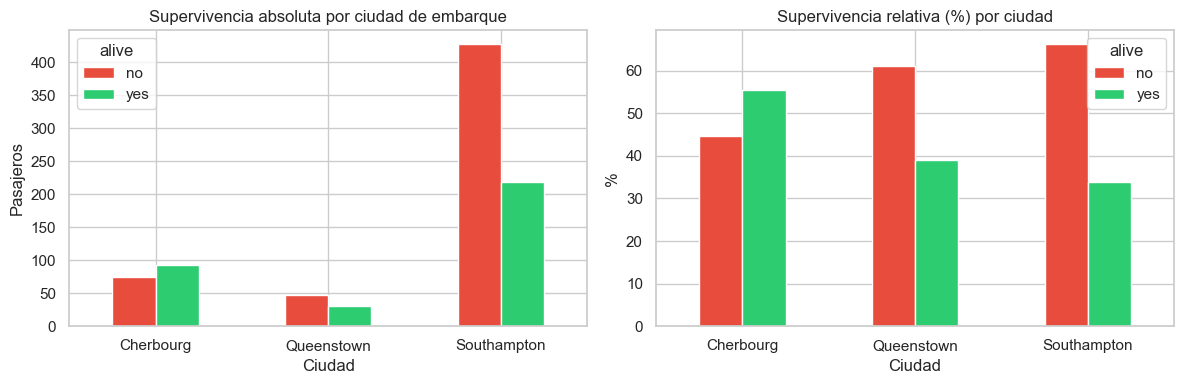

Test Chi² (ciudad vs supervivencia): chi2=25.96, p=0.000002
Relación estadísticamente significativa


In [9]:
#3

abs_ciudad = pd.crosstab(df['embark_town'], df['alive'])
rel_ciudad = pd.crosstab(df['embark_town'], df['alive'], normalize='index').round(3) * 100

print("Absoluto:")
print(abs_ciudad)
print("\nRelativo (%):")
print(rel_ciudad)


fig, axes = plt.subplots(1, 2, figsize=(12, 4))

abs_ciudad.plot(kind='bar', ax=axes[0], color=['#e74c3c','#2ecc71'], rot=0)
axes[0].set_title("Supervivencia absoluta por ciudad de embarque")
axes[0].set_xlabel("Ciudad"); axes[0].set_ylabel("Pasajeros")

rel_ciudad.plot(kind='bar', ax=axes[1], color=['#e74c3c','#2ecc71'], rot=0)
axes[1].set_title("Supervivencia relativa (%) por ciudad")
axes[1].set_xlabel("Ciudad"); axes[1].set_ylabel("%")

plt.tight_layout()
plt.show()


chi2, p, dof, exp = chi2_contingency(abs_ciudad)
print(f"Test Chi² (ciudad vs supervivencia): chi2={chi2:.2f}, p={p:.6f}")
print("Relación estadísticamente significativa" if p < 0.05 else "No significativa")


**Conclusión:** En absoluto, Southampton tuvo más supervivientes (219) por ser la ciudad con más embarques. En relativo, **Cherbourg** destaca con el 55% de supervivencia, frente al 39% de Queenstown y el 34% de Southampton. Esto está relacionado con que en Cherbourg embarcaron más pasajeros de primera clase.

Tarifa media  — Supervivientes: 48.40 £  |  Fallecidos: 22.12 £
Tarifa mediana — Supervivientes: 26.00 £  |  Fallecidos: 10.50 £


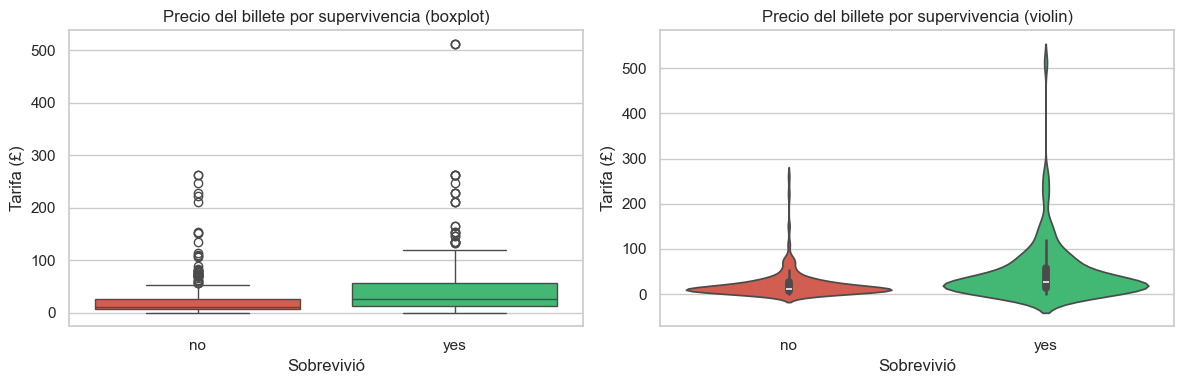

Test Mann-Whitney U (fare vs alive): U=129952, p=0.000000
Diferencia estadísticamente SIGNIFICATIVA


In [10]:
#4

fare_vivos = df[df['alive'] == 'yes']['fare']
fare_muertos = df[df['alive'] == 'no']['fare']
print(f"Tarifa media  — Supervivientes: {fare_vivos.mean():.2f} £  |  Fallecidos: {fare_muertos.mean():.2f} £")
print(f"Tarifa mediana — Supervivientes: {fare_vivos.median():.2f} £  |  Fallecidos: {fare_muertos.median():.2f} £")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.boxplot(data=df, x='alive', y='fare',
            hue='alive', palette={'yes':'#2ecc71','no':'#e74c3c'},
            legend=False, ax=axes[0])
axes[0].set_title("Precio del billete por supervivencia (boxplot)")
axes[0].set_xlabel("Sobrevivió"); axes[0].set_ylabel("Tarifa (£)")

sns.violinplot(data=df, x='alive', y='fare',
               hue='alive', palette={'yes':'#2ecc71','no':'#e74c3c'},
               legend=False, ax=axes[1])
axes[1].set_title("Precio del billete por supervivencia (violin)")
axes[1].set_xlabel("Sobrevivió"); axes[1].set_ylabel("Tarifa (£)")

plt.tight_layout()
plt.show()

stat, p = mannwhitneyu(fare_vivos, fare_muertos, alternative='two-sided')
print(f"Test Mann-Whitney U (fare vs alive): U={stat:.0f}, p={p:.6f}")
print("Diferencia estadísticamente SIGNIFICATIVA" if p < 0.05 else "No significativa")

**Conclusión:** Los supervivientes pagaron tarifas significativamente más altas (media ~49£) frente a los fallecidos (~22£). Esto refleja la correlación con la clase: mayor precio, mayor probabilidad de ser de primera clase, mayor supervivencia. El test de Mann-Whitney confirma que la diferencia es estadísticamente significativa.

In [11]:
#5

gratuitos = df[df['fare'] == 0]
print(f"Pasajeros con billete gratuito: {len(gratuitos)}")
print(f"  - Por clase:   { dict(gratuitos['class'].value_counts()) }")
print(f"  - Sobrevivieron: { dict(gratuitos['alive'].value_counts()) }")
print(f"  - Grupo (who): { dict(gratuitos['who'].value_counts()) }")
print(f"  - Ciudad:      { dict(gratuitos['embark_town'].value_counts()) }")


max_fare = df['fare'].max()
mas_caro = df[df['fare'] == max_fare][['who', 'alive', 'class', 'embark_town', 'fare', 'family_members']]
print(f"Tarifa máxima: {max_fare:.2f} £")
print(f"Número de pasajeros con esa tarifa: {len(mas_caro)}")
print()
print(mas_caro.to_string(index=True))


Pasajeros con billete gratuito: 15
  - Por clase:   {'Second': np.int64(6), 'First': np.int64(5), 'Third': np.int64(4)}
  - Sobrevivieron: {'no': np.int64(14), 'yes': np.int64(1)}
  - Grupo (who): {'man': np.int64(15)}
  - Ciudad:      {'Southampton': np.int64(15)}
Tarifa máxima: 512.33 £
Número de pasajeros con esa tarifa: 3

       who alive  class embark_town      fare  family_members
258  woman   yes  First   Cherbourg  512.3292               0
679    man   yes  First   Cherbourg  512.3292               1
737    man   yes  First   Cherbourg  512.3292               0


**Conclusión:** Los 15 pasajeros con tarifa 0 son todos hombres adultos y la gran mayoría no sobrevivió. Probablemente eran **tripulantes, empleados del barco o invitados** que viajaban de forma gratuita. La tarifa más alta fue **512.33£**, pagada por 3 pasajeros (2 hombres y 1 mujer), todos de primera clase y embarcados en Cherbourg. Los tres sobrevivieron.

Tarifa media por ciudad y supervivencia:
             Fallecidos (£)  Supervivientes (£)
embark_town                                    
Cherbourg             35.44               79.72
Queenstown            13.34               13.18
Southampton           20.74               39.92


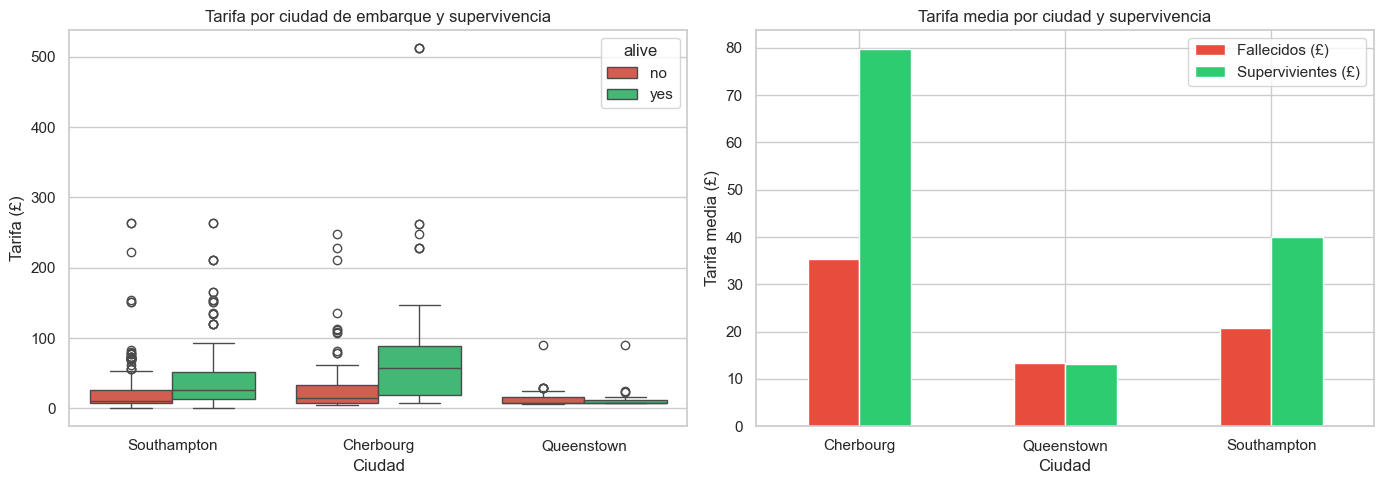

In [12]:
#6

tabla_p6 = df.groupby(['embark_town', 'alive'])['fare'].mean().unstack().round(2)
tabla_p6.columns = ['Fallecidos (£)', 'Supervivientes (£)']
print("Tarifa media por ciudad y supervivencia:")
print(tabla_p6)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))


sns.boxplot(data=df, x='embark_town', y='fare', hue='alive',
            palette={'yes':'#2ecc71','no':'#e74c3c'}, ax=axes[0])
axes[0].set_title("Tarifa por ciudad de embarque y supervivencia")
axes[0].set_xlabel("Ciudad"); axes[0].set_ylabel("Tarifa (£)")


tabla_p6.plot(kind='bar', ax=axes[1], color=['#e74c3c','#2ecc71'], rot=0)
axes[1].set_title("Tarifa media por ciudad y supervivencia")
axes[1].set_xlabel("Ciudad"); axes[1].set_ylabel("Tarifa media (£)")

plt.tight_layout()
plt.show()

**Conclusión:** En Cherbourg, tanto supervivientes como fallecidos pagaron tarifas mucho más altas que en Southampton o Queenstown. Esto se explica porque en Cherbourg embarcaron principalmente pasajeros de primera clase. Existe una clara correlación entre ciudad, clase, precio, supervivencia.

Supervivencia absoluta y relativa por clase y grupo:
alive          no  yes  total  pct_supervivencia
class  who                                      
Second child    0   19     19              100.0
First  woman    2   89     91               97.8
Second woman    6   60     66               90.9
First  child    1    5      6               83.3
Third  woman   58   56    114               49.1
       child   33   25     58               43.1
First  man     77   42    119               35.3
Third  man    281   38    319               11.9
Second man     91    8     99                8.1


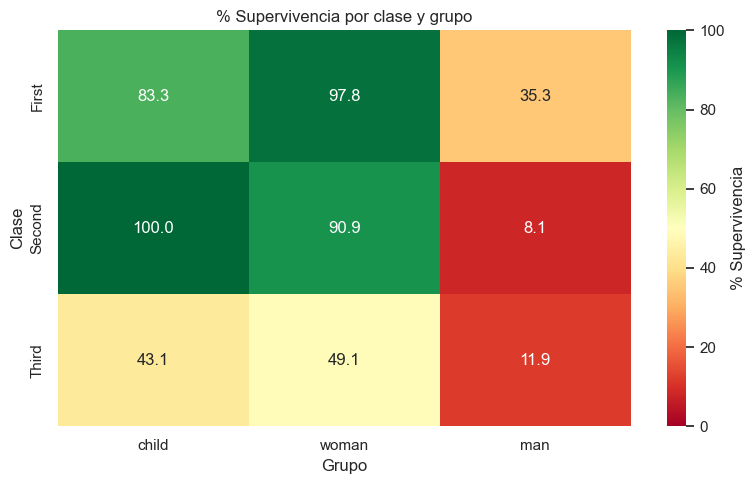

In [13]:
#7

tabla_p7 = df.groupby(['class', 'who'])['alive'].value_counts().unstack(fill_value=0)
tabla_p7['total'] = tabla_p7.sum(axis=1)
tabla_p7['pct_supervivencia'] = (tabla_p7['yes'] / tabla_p7['total'] * 100).round(1)

print("Supervivencia absoluta y relativa por clase y grupo:")
print(tabla_p7.sort_values('pct_supervivencia', ascending=False))


pivot = df.pivot_table(values='alive', index='class', columns='who',
                        aggfunc=lambda x: (x=='yes').sum() / len(x) * 100)

orden_class = ['First', 'Second', 'Third']
orden_who = ['child', 'woman', 'man']
pivot = pivot.loc[orden_class, orden_who]

plt.figure(figsize=(8, 5))
sns.heatmap(pivot, annot=True, fmt='.1f', cmap='RdYlGn',
            vmin=0, vmax=100, cbar_kws={'label': '% Supervivencia'})
plt.title("% Supervivencia por clase y grupo")
plt.xlabel("Grupo"); plt.ylabel("Clase")
plt.tight_layout()
plt.show()

**Conclusión:** En absoluto, los hombres de tercera clase son el grupo con más fallecidos (281). En términos relativos, las **mujeres de primera clase** tienen la tasa más alta (97.8%), seguidas de las mujeres de segunda (90.9%). El grupo más desfavorecido fueron los **hombres de segunda clase** (solo 8.1% sobrevivieron). Los niños de segunda clase sobrevivieron todos (100%). El patrón 'mujeres y niños primero' es evidente, pero mediado por la clase social.

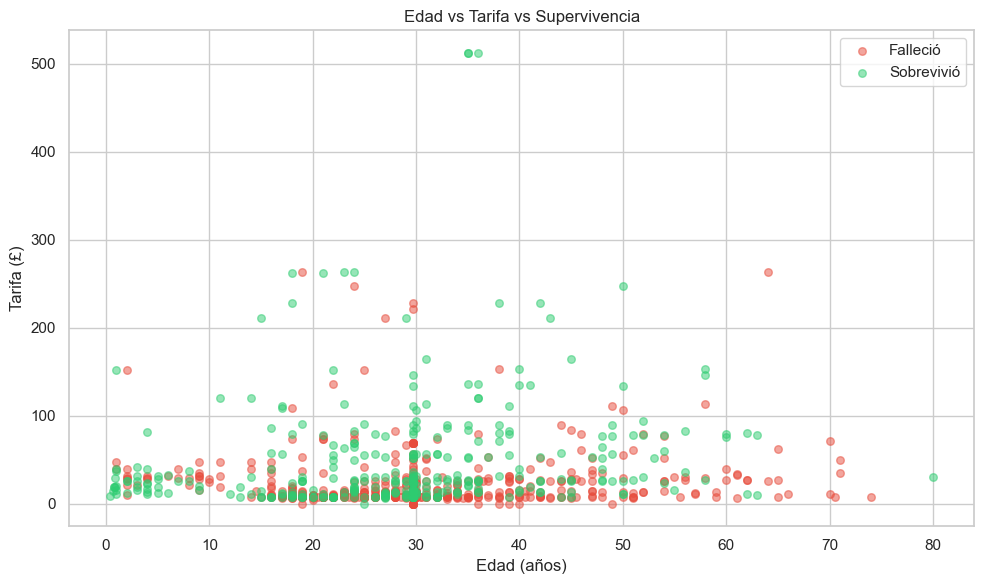

Correlación Pearson (age vs fare): r=0.092, p=0.0062

Estadísticas de edad por supervivencia:
       count   mean    std   min   25%   50%   75%   max
alive                                                   
no     549.0  30.42  12.46  1.00  23.0  29.7  35.0  74.0
yes    342.0  28.55  13.77  0.42  21.0  29.7  35.0  80.0


In [14]:
#8

plt.figure(figsize=(10, 6))
colores = {'yes': '#2ecc71', 'no': '#e74c3c'}

for estado, grupo in df.groupby('alive'):
    plt.scatter(grupo['age'], grupo['fare'],
                alpha=0.5, label=f"{'Sobrevivió' if estado=='yes' else 'Falleció'}",
                color=colores[estado], s=30)

plt.xlabel("Edad (años)")
plt.ylabel("Tarifa (£)")
plt.title("Edad vs Tarifa vs Supervivencia")
plt.legend()
plt.tight_layout()
plt.show()

corr, p_corr = stats.pearsonr(df['age'], df['fare'])
print(f"Correlación Pearson (age vs fare): r={corr:.3f}, p={p_corr:.4f}")

print("\nEstadísticas de edad por supervivencia:")
print(df.groupby('alive')['age'].describe().round(2))

**Conclusión:** El scatter muestra que las tarifas altas están mayoritariamente asociadas a supervivientes, independientemente de la edad. La edad por sí sola tiene poca correlación con la tarifa (r ≈ 0.1). Sin embargo, se observa que los pasajeros más jóvenes con tarifas bajas (tercera clase) tienen peores tasas de supervivencia. La tarifa es el predictor más potente de supervivencia, más que la edad en sí.

## #EXTRA: Viajes

El objetivo en este caso no es tanto hacer un montón de análisis sino de completar lo que quedó pendiente en el workout y de entender cómo de un dataset podemos obtener preguntas o hipótesis interesantes (si las hay)

### #EXTRA.1 

Carga el dataset de viajes del mes de junio. Repite el análisis bivariante entre las variables "Aircompany" e "Ingresos", mostrando previamente los viajes por compañía aérea. ¿Qué situación llamativa nos surgió? (Ten en cuenta que somos el departamenteo de DataScience de TabarAir)

Shape: (600, 11)

Viajes por compañía aérea:
aircompany
TabarAir      142
MoldaviAir    133
PamPangea     117
FlyQ          108
Airnar        100
Name: count, dtype: int64
Ingresos medios por compañía (€):
aircompany
MoldaviAir    548077.21
PamPangea     478417.05
Airnar        405293.98
FlyQ          401619.01
TabarAir      271042.23
Name: ingresos, dtype: float64


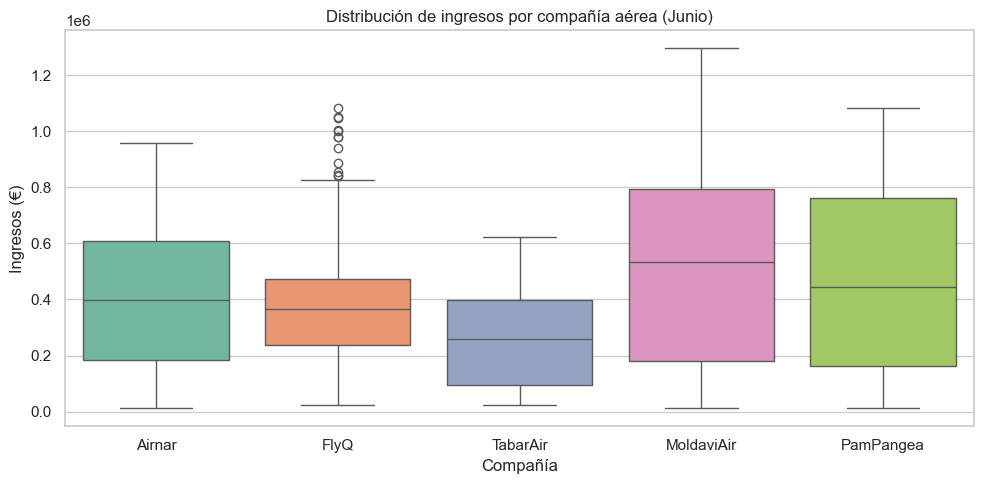

In [15]:
df_viajes = pd.read_csv("./data/dataset_viajes_jun.csv")
print("Shape:", df_viajes.shape)
print("\nViajes por compañía aérea:")
print(df_viajes['aircompany'].value_counts())


print("Ingresos medios por compañía (€):")
print(df_viajes.groupby('aircompany')['ingresos'].mean().sort_values(ascending=False).round(2))


plt.figure(figsize=(10, 5))
sns.boxplot(data=df_viajes, x='aircompany', y='ingresos',
            hue='aircompany', palette='Set2', legend=False)
plt.title("Distribución de ingresos por compañía aérea (Junio)")
plt.xlabel("Compañía"); plt.ylabel("Ingresos (€)")
plt.tight_layout(); plt.show()


**Situación llamativa:** Siendo el departamento de DataScience de **TabarAir**, observamos que nuestra compañía tiene los ingresos medios más bajos (~271.000€), muy por debajo de MoldaviAir (~548.000€) o PamPangea (~478.000€). Sin embargo, TabarAir es la compañía con **más vuelos** (142). La pregunta clave es si compensamos en volumen o si somos menos rentables por vuelo.

### #EXTRA.2

Repite el análisis multivariante entre "ingresos","distancias" y "consumo_kg". ¿Qué veíamos que parecía también muy prometedor?

Matriz de correlación:
            ingresos  distancia  consumo_kg
ingresos       1.000      0.929       0.945
distancia      0.929      1.000       0.762
consumo_kg     0.945      0.762       1.000


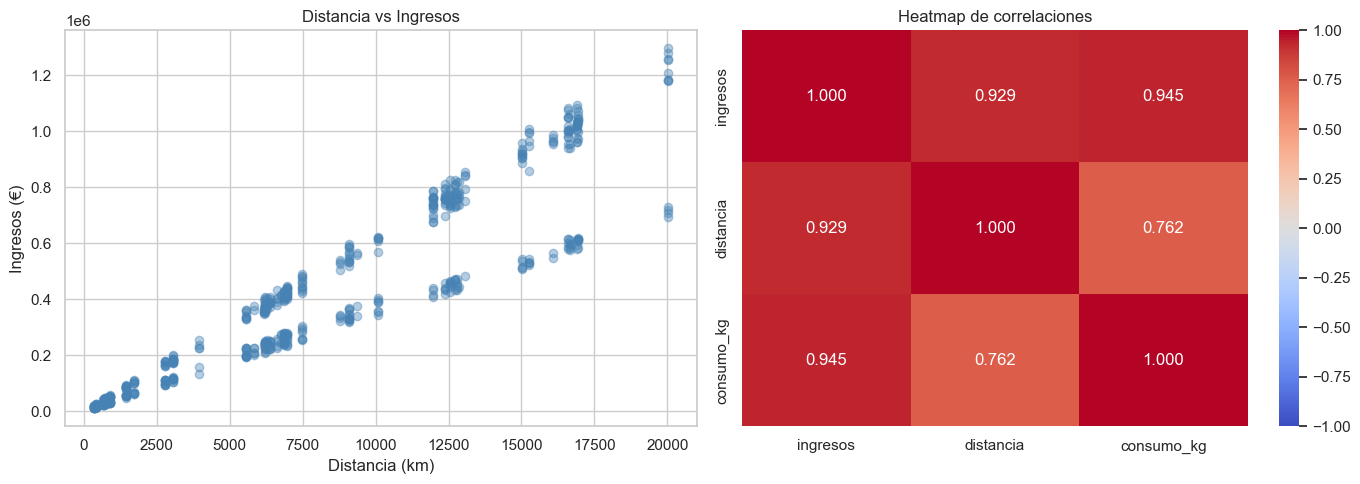

In [16]:
corr_matrix = df_viajes[['ingresos', 'distancia', 'consumo_kg']].corr()
print("Matriz de correlación:")
print(corr_matrix.round(3))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(df_viajes['distancia'], df_viajes['ingresos'], alpha=0.4, color='steelblue')
axes[0].set_title("Distancia vs Ingresos")
axes[0].set_xlabel("Distancia (km)"); axes[0].set_ylabel("Ingresos (€)")

sns.heatmap(corr_matrix, annot=True, fmt='.3f', cmap='coolwarm',
            vmin=-1, vmax=1, ax=axes[1])
axes[1].set_title("Heatmap de correlaciones")

plt.tight_layout(); plt.show()


**Observación:** Existe una correlación muy alta entre `distancia` e `ingresos` (r = 0.93) y entre `consumo_kg` e `ingresos` (r = 0.94). Esto significa que los vuelos más largos generan muchos más ingresos — y también consumen más. TabarAir, con ingresos más bajos, probablemente opera rutas más cortas que el resto.

### #EXTRA.3

Crea una variable categorica "cat_vuelo" a partir de distancias, escoge los rangos de las categorías basándote en la distribución de valores de "distancia" (sugerencia entre 3 y 4 categorías). Extra: Reaiza ahora otra vez el análisis multivariante "cat_vuelo", "ingresos", "consumo_kg". ¿Ves algo diferente?

Distribución de distancias:
count      600.0
mean      8071.0
std       5550.2
min        344.0
25%       3073.0
50%       6877.0
75%      12553.0
max      20029.0
Name: distancia, dtype: float64


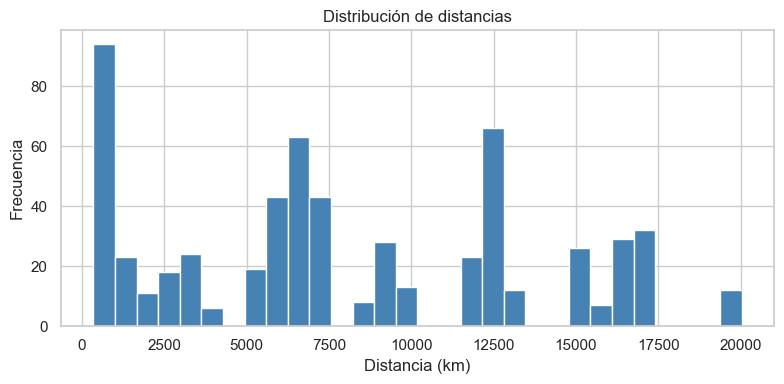

Distribución de categorías de vuelo:
cat_vuelo
Corto          146
Medio          180
Largo          162
Ultra-largo    112
Name: count, dtype: int64


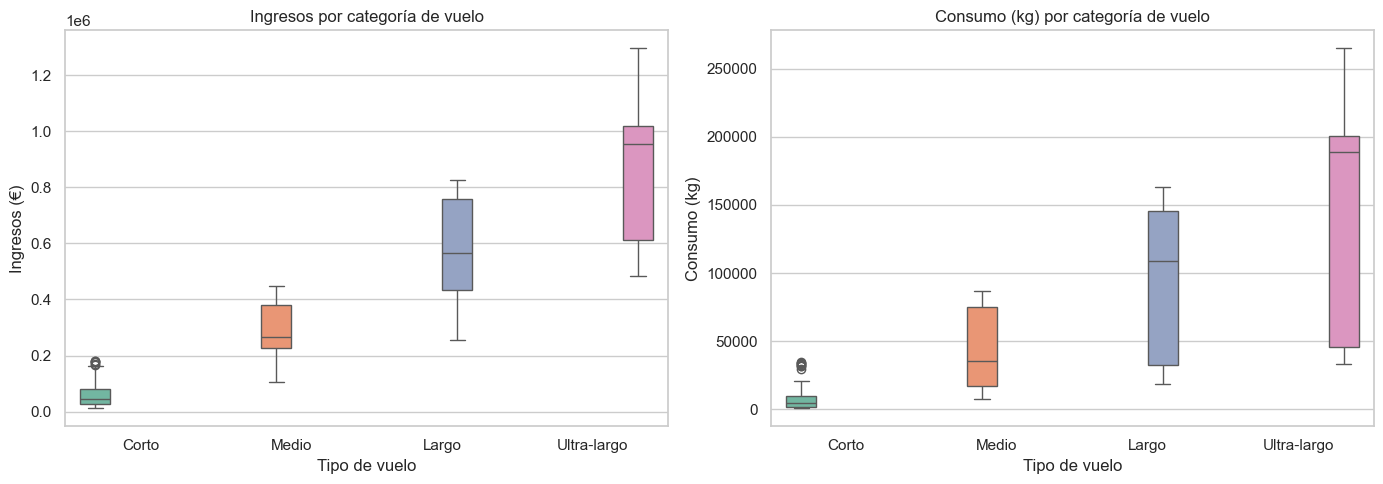

Rentabilidad media (€/kg combustible) por tipo de vuelo:
cat_vuelo
Corto          9.87
Medio          9.35
Largo          8.31
Ultra-largo    7.80
Name: rentabilidad, dtype: float64

Vuelos de TabarAir por categoría:
cat_vuelo
Corto          36
Medio          62
Largo          44
Ultra-largo     0
Name: count, dtype: int64


In [17]:
print("Distribución de distancias:")
print(df_viajes['distancia'].describe().round(1))
df_viajes['distancia'].hist(bins=30, figsize=(8,4), color='steelblue', edgecolor='white')
plt.title("Distribución de distancias"); plt.xlabel("Distancia (km)"); plt.ylabel("Frecuencia")
plt.tight_layout(); plt.show()


bins   = [0, 3000, 7000, 13000, df_viajes['distancia'].max() + 1]
labels = ['Corto', 'Medio', 'Largo', 'Ultra-largo']

df_viajes['cat_vuelo'] = pd.cut(df_viajes['distancia'], bins=bins, labels=labels)

print("Distribución de categorías de vuelo:")
print(df_viajes['cat_vuelo'].value_counts().sort_index())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(data=df_viajes, x='cat_vuelo', y='ingresos',
            hue='cat_vuelo', order=labels, palette='Set2', legend=False, ax=axes[0])
axes[0].set_title("Ingresos por categoría de vuelo")
axes[0].set_xlabel("Tipo de vuelo"); axes[0].set_ylabel("Ingresos (€)")

sns.boxplot(data=df_viajes, x='cat_vuelo', y='consumo_kg',
            hue='cat_vuelo', order=labels, palette='Set2', legend=False, ax=axes[1])
axes[1].set_title("Consumo (kg) por categoría de vuelo")
axes[1].set_xlabel("Tipo de vuelo"); axes[1].set_ylabel("Consumo (kg)")

plt.tight_layout(); plt.show()

df_viajes['rentabilidad'] = df_viajes['ingresos'] / df_viajes['consumo_kg']
print("Rentabilidad media (€/kg combustible) por tipo de vuelo:")
print(df_viajes.groupby('cat_vuelo', observed=True)['rentabilidad'].mean().round(2))


print("\nVuelos de TabarAir por categoría:")
print(df_viajes[df_viajes['aircompany']=='TabarAir']['cat_vuelo'].value_counts().sort_index())

**Diferencias** Al categorizar los vuelos, se confirma visualmente que los vuelos 'Ultra-largo' generan ingresos muy superiores. Además, viendo dónde se concentra TabarAir en el reparto por categorías, se entiende mejor por qué tiene ingresos medios más bajos: opera más vuelos cortos y medios que el resto de compañías. Esto permite plantear una estrategia de negocio basada en ampliar rutas de largo radio.